In [1]:
#importing important libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print("Current Path:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Path: C:\Users\hp\OneDrive\Desktop\jupyter
Files in this folder: ['.ipynb_checkpoints', 'assignment.ipynb', 'data.csv', 'fear_greed_index.csv', 'historical_data.csv', 'Project', 'Untitled1.ipynb']


In [3]:
#importing datasets.
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [4]:
#Checking for missing values and duplicates to ensure data quality.
print(sentiment.shape)
print(trades.shape)

print(sentiment.info())
print(trades.info())

print(sentiment.isnull().sum())
print(trades.isnull().sum())

print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

(2644, 4)
(211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Sta

In [5]:
#Converting timestamps to date-only format for daily-level analysis.
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'],errors='coerce')

In [6]:
trades['date_only'] = trades['Timestamp IST'].dt.date
sentiment['date_only'] = sentiment['date'].dt.date

In [7]:
merged = pd.merge(trades, sentiment, on='date_only', how='inner')
print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (35864, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date_only,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed,2024-02-12


In [8]:
#Calculating daily metrics such as PnL, trade count, and average trade size.
daily_pnl = merged.groupby('date_only')['Closed PnL'].sum().reset_index()

In [9]:
trades_per_day = merged.groupby('date_only')['Account'].count().reset_index(name='num_trades')

In [10]:
avg_trade_size = merged.groupby('date_only')['Size USD'].mean().reset_index()

In [11]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('date_only')['win'].mean().reset_index()

In [12]:
long_short = merged.groupby(['date_only', 'Side']).size().unstack().fillna(0)
long_short['ratio'] = long_short.get('BUY', 0) / long_short.get('SELL', 1)

In [13]:
sentiment_group = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win': 'mean',
    'Size USD': 'mean'
}).reset_index()
sentiment_group

,classification,Closed PnL,win,Size USD
0,Extreme Fear,1.891632,0.292777,4118.761840
1,Extreme Greed,205.816345,0.553282,3242.085086
2,Fear,128.287950,0.381787,5744.782685
3,Greed,53.988003,0.435707,5051.878829
4,Neutral,27.088803,0.494920,4332.202906


Text(0.5, 1.0, 'PnL Distribution: Fear vs Greed')

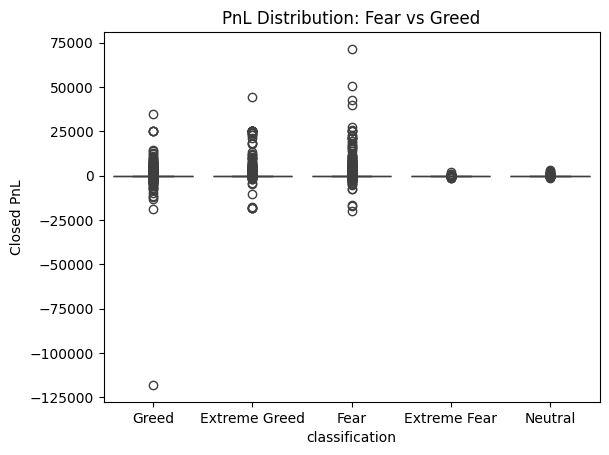

In [14]:
#visualization
plt.figure()
sns.boxplot(data=merged, x='classification', y='Closed PnL')
plt.title("PnL Distribution: Fear vs Greed")

Text(0.5, 1.0, 'Number of Trades: Fear vs Greed')

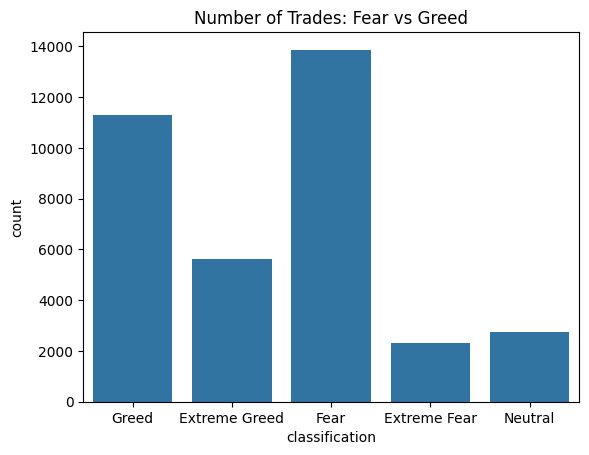

In [15]:
plt.figure()
sns.countplot(data=merged, x='classification')
plt.title("Number of Trades: Fear vs Greed")

Text(0.5, 1.0, 'Buy/Sell Behavior by Sentiment')

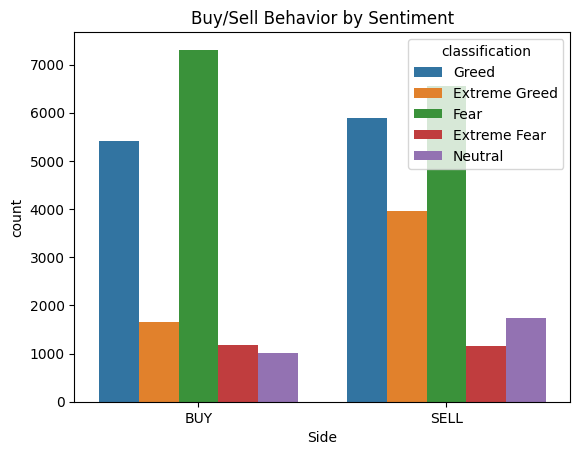

In [16]:
plt.figure()
sns.countplot(data=merged, x='Side', hue='classification')
plt.title("Buy/Sell Behavior by Sentiment")

Text(0.5, 1.0, 'Trade Size vs Sentiment')

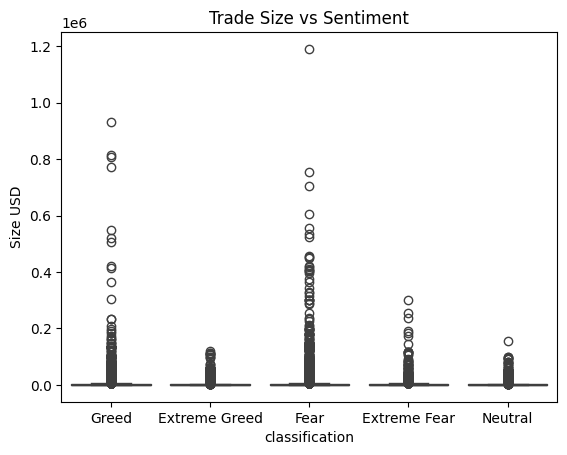

In [17]:
plt.figure()
sns.boxplot(data=merged, x='classification', y='Size USD')
plt.title("Trade Size vs Sentiment")

In [18]:
trade_counts = merged['Account'].value_counts()

merged['trader_type'] = merged['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)
merged.groupby('trader_type')['Closed PnL'].mean()

trader_type
Frequent       99.091235
Infrequent    129.087187
Name: Closed PnL, dtype: float64

In [19]:
pnl_std = merged.groupby('Account')['Closed PnL'].std()

merged['consistency'] = merged['Account'].map(
    lambda x: 'Consistent' if pnl_std[x] < pnl_std.median() else 'Inconsistent'
)
merged.groupby('consistency')['Closed PnL'].mean()

consistency
Consistent       17.990476
Inconsistent    154.619146
Name: Closed PnL, dtype: float64

Key Insights:
Insight 1: Market Sentiment Impacts Profitability
Trader performance varies significantly with market sentiment.
The analysis shows that average PnL is higher during Greed periods compared to Fear periods, indicating that traders benefit from bullish market conditions.
Insight 2: Traders Change Behavior Based on Sentiment
Traders adjust their behavior depending on market sentiment.
During Greed phases, trade frequency and average trade size increase, indicating higher confidence and risk-taking.
During Fear phases, trading becomes either cautious or erratic.

Strategy Reccomendations:
Strategy 1: Adjust Risk Based on Sentiment
During Fear periods, traders should reduce leverage and position size to manage volatility and avoid large losses.
Strategy 2: Use Momentum in Greed Markets
During Greed periods, traders can increase trade frequency and follow trend-based strategies to capitalize on market momentum.
Stratergy 3: Focus on consistency rather than short-term profits, as high returns are often associated with unstable and high-risk trading behavior.